In [2]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#importing the dataset
dataset = pd.read_csv('uber-rides-2016.csv')
dataset.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


Inspecting data set

In [5]:
dataset.shape

(1156, 7)

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   object 
 1   END_DATE*    1155 non-null   object 
 2   CATEGORY*    1155 non-null   object 
 3   START*       1155 non-null   object 
 4   STOP*        1155 non-null   object 
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [9]:
dataset.describe()

,MILES*
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


Observations:

*The dataset contains a few missing values in multiple columns (notably 43% of PURPOSE* values).
*MILES* values vary significantly — likely due to some long intercity trips.
*Dates are currently stored as strings (object type), so they’ll need conversion to datetime for time-based analysis.
*Column names contain * characters — it’ll be cleaner to rename them

Next Step: Data cleaning and preparation

In [11]:
#rename columns to remove * characters
dataset.columns = [col.replace('*', '') for col in dataset.columns]
dataset.head(2)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN


Handling missing values

In [13]:
#checking for missing values
dataset.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [14]:
#drop rows with missing critical values
dataset = dataset.dropna(subset=['START_DATE','END_DATE','START','STOP','MILES'])
dataset.isnull().sum()

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       502
dtype: int64

In [ ]:
#replacing missing PURPOSE values with 'Unknown'
dataset['PURPOSE'] = dataset['PURPOSE'].fillna('Unknown')
dataset.isnull().sum()

C:\Users\Manuj\AppData\Local\Temp\ipykernel_77788\2457281034.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['PURPOSE'] = dataset['PURPOSE'].fillna('Unknown')


START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

converting dates and feature extraction

In [16]:
#converting date columns to datetime
dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'],errors='coerce')
dataset['END_DATE'] = pd.to_datetime(dataset['END_DATE'],errors='coerce')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1155 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1155 non-null   datetime64[ns]
 1   END_DATE    1155 non-null   datetime64[ns]
 2   CATEGORY    1155 non-null   object        
 3   START       1155 non-null   object        
 4   STOP        1155 non-null   object        
 5   MILES       1155 non-null   float64       
 6   PURPOSE     1155 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 72.2+ KB


C:\Users\Manuj\AppData\Local\Temp\ipykernel_77788\2326602647.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'],errors='coerce')
C:\Users\Manuj\AppData\Local\Temp\ipykernel_77788\2326602647.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['END_DATE'] = pd.to_datetime(dataset['END_DATE'],errors='coerce')


In [18]:
#extracting time-based features
dataset.loc[:,'START_HOUR'] = dataset['START_DATE'].dt.hour
dataset.loc[:,'START_DAY'] = dataset['START_DATE'].dt.day
dataset.loc[:,'START_MONTH'] = dataset['START_DATE'].dt.month
dataset.loc[:,'START_DATE_ONLY'] = dataset['START_DATE'].dt.date
dataset.head(2)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,START_HOUR,START_DAY,START_MONTH,START_DATE_ONLY
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21,1,1,2016-01-01
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,1,2,1,2016-01-02


Exploratory data analysis

In [20]:
#basic statistics
print("Total Rides:", len(dataset))
print("Total Miles:", dataset['MILES'].sum())
print("Average Miles per Ride:", dataset['MILES'].mean())
print("\nCategory distribution:")
print(dataset['CATEGORY'].value_counts())
print("\nPurpose distribution (Top 10):")
print(dataset['PURPOSE'].value_counts().head(10))

Total Rides: 1155
Total Miles: 12204.7
Average Miles per Ride: 10.566839826839827

Category distribution:
CATEGORY
Business    1078
Personal      77
Name: count, dtype: int64

Purpose distribution (Top 10):
PURPOSE
Unknown            502
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Commute              1
Name: count, dtype: int64


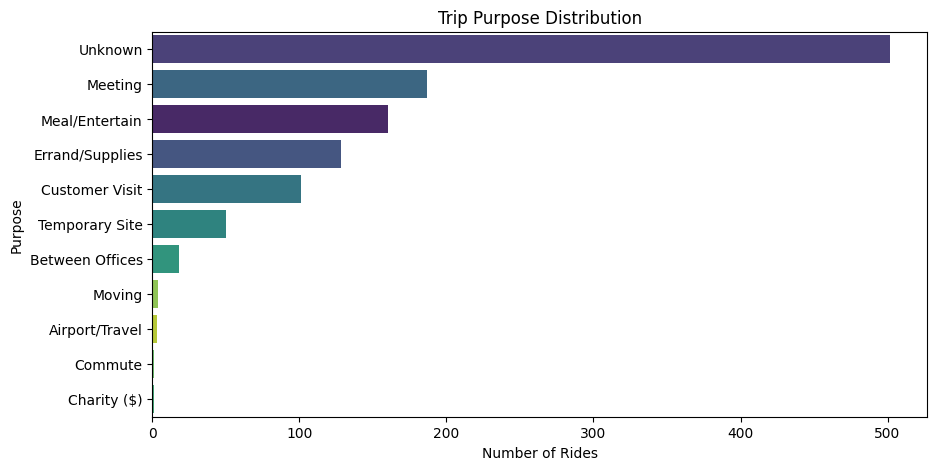

In [27]:
#trip purpose distribution
plt.figure(figsize=(10,5))
sns.countplot(data=dataset, y='PURPOSE', hue='PURPOSE', legend=False, order=dataset['PURPOSE'].value_counts().index, palette='viridis')
plt.title('Trip Purpose Distribution')
plt.xlabel('Number of Rides')
plt.ylabel('Purpose')
plt.show()

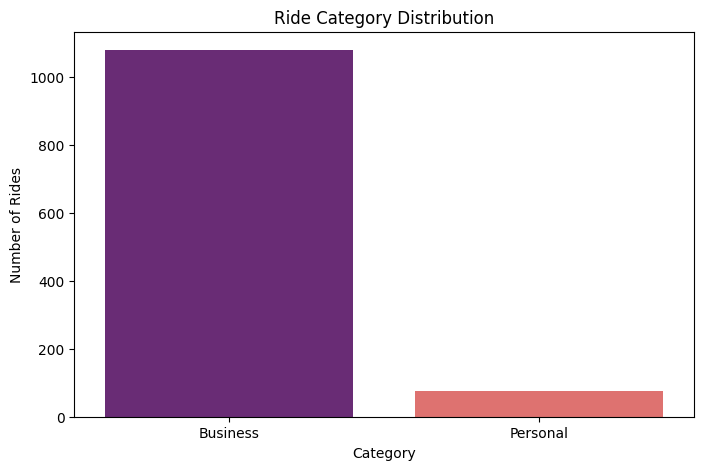

In [36]:
#category distribution
category_counts = dataset['CATEGORY'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=category_counts.index, hue=category_counts.index, legend=False, y=category_counts.values, palette='magma')
plt.title('Ride Category Distribution') 
plt.xlabel('Category')
plt.ylabel('Number of Rides')
plt.show()

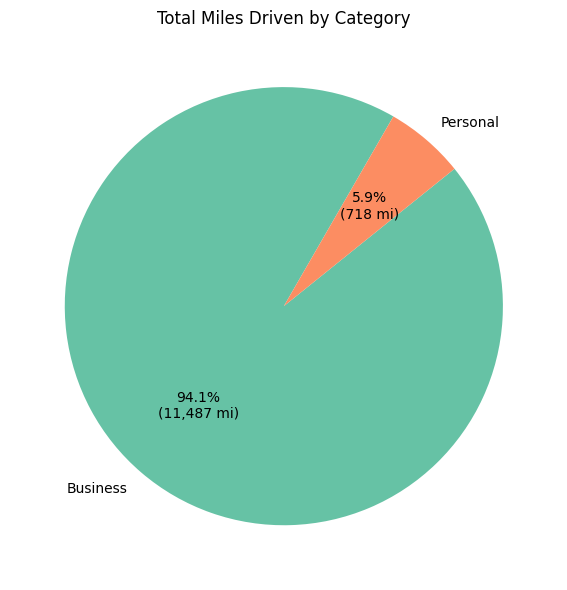

Category Miles Distribution: CATEGORY
Business    11487.0
Personal      717.7
Name: MILES, dtype: float64


In [51]:
#category miles distribution
category_miles = dataset.groupby('CATEGORY')['MILES'].sum().sort_values(ascending=False)

# Custom label formatter to show both miles & percentage
def miles_pct_label(pct, allvals):
    absolute = int(round(pct/100. * sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,} mi)"

plt.figure(figsize=(6,6))
plt.pie(
    category_miles,
    labels=category_miles.index,
    autopct=lambda pct: miles_pct_label(pct, category_miles.values),
    startangle=60,
    colors=sns.color_palette('Set2')
)

plt.title('Total Miles Driven by Category')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("Category Miles Distribution:", category_miles)


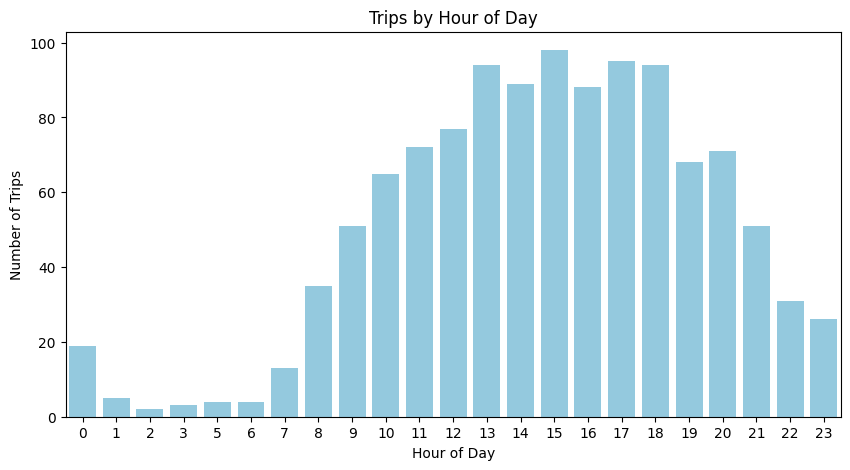

In [ ]:
#trip distribution by hour
plt.figure(figsize=(10,5))
sns.countplot(x='START_HOUR', data=dataset, color='skyblue')
plt.title('Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0,24))
plt.show()

C:\Users\Manuj\AppData\Local\Temp\ipykernel_77788\1159786405.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='START_WEEKDAY', data=dataset,


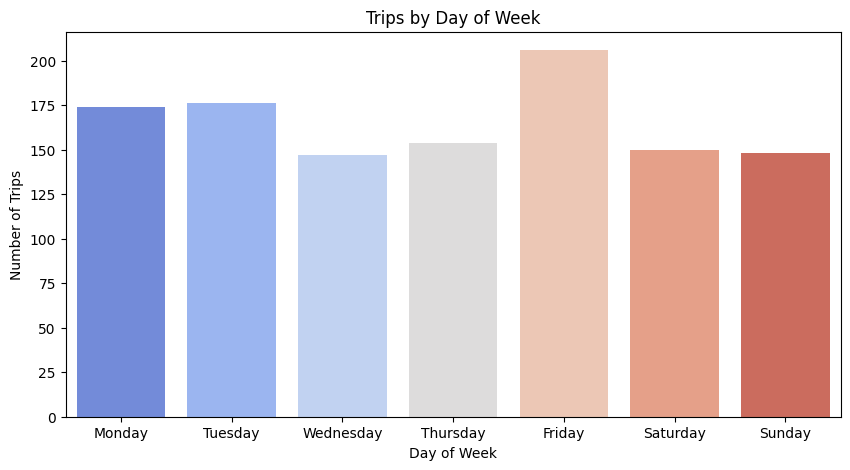

In [56]:
#trips by day
dataset.loc[:,'START_WEEKDAY'] = dataset['START_DATE'].dt.day_name()

plt.figure(figsize=(10,5))
sns.countplot(x='START_WEEKDAY', data=dataset,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
              palette='coolwarm')
plt.title('Trips by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.show()

C:\Users\Manuj\AppData\Local\Temp\ipykernel_77788\2476628494.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_routes.index, x=top_routes.values, palette='magma')


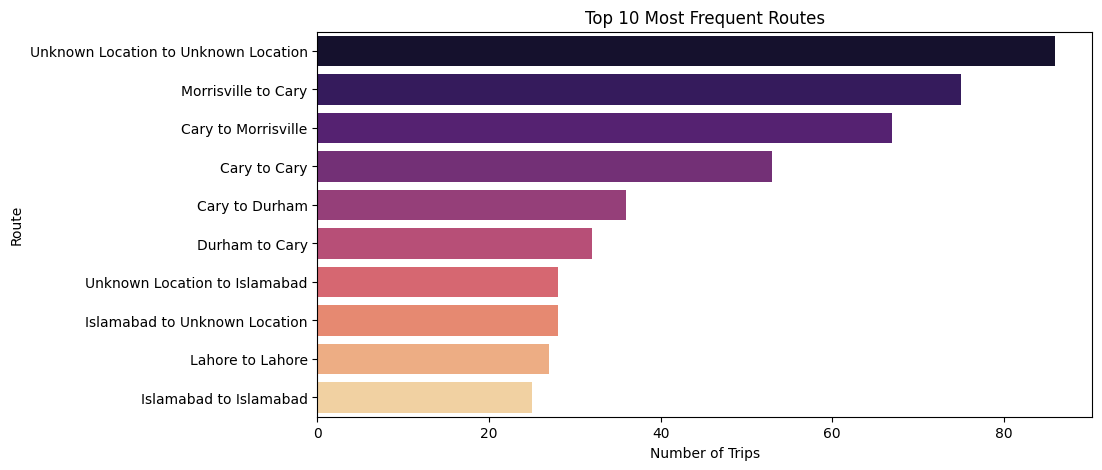

In [58]:
#mostfrequent routes
dataset.loc[:,'ROUTE'] = dataset['START'] + " to " + dataset['STOP']
top_routes = dataset['ROUTE'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(y=top_routes.index, x=top_routes.values, palette='magma')
plt.title('Top 10 Most Frequent Routes')
plt.xlabel('Number of Trips')
plt.ylabel('Route')
plt.show()